## Libraries

In [16]:
# Prevent OpenMP runtime conflict between libraries like PyTorch, TensorFlow, and NumPy on Windows
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import os
sys.path.append(os.path.abspath(".."))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from torchmetrics.classification import MulticlassAccuracy

from tqdm.auto import tqdm
import numpy as np
from prettytable import PrettyTable

from danflow.training import Trainer
from danflow.visualization import plot_training_history

## Load Data

In [2]:
data = torch.load('../saved_values/shuttle_data.pt', weights_only=False)

x_train = data["x_train"]
y_train = data["y_train"]

x_valid = data["x_valid"]
y_valid = data["y_valid"]

x_test = data["x_test"]
y_test = data["y_test"]

## Convert to Tensors

In [3]:
x_train = torch.tensor(np.asarray(x_train), dtype=torch.float32)
y_train = torch.tensor(np.asarray(y_train), dtype=torch.long)

x_valid = torch.tensor(np.asarray(x_valid), dtype=torch.float32)
y_valid = torch.tensor(np.asarray(y_valid), dtype=torch.long)

x_test = torch.tensor(np.asarray(x_test), dtype=torch.float32)
y_test = torch.tensor(np.asarray(y_test), dtype=torch.long)

## Data Loader

In [4]:
train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

valid_dataset = TensorDataset(x_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=256)

test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=256)

## **Debugging** | Check Dataset and Target Distribution

In [18]:
print("Train X shape:", x_train.shape)
print("Train y shape:", y_train.shape)

print("\nValidation X shape:", x_valid.shape)
print("Validation y shape:", y_valid.shape)

print("\nTest X shape:", x_test.shape)
print("Test y shape:", y_test.shape)

print("\nTarget dtype:", y_train.dtype)

print("\nTarget classes:")
print(torch.unique(y_train))

print("\nTarget distribution:")
print(torch.bincount(y_train))

Train X shape: torch.Size([30450, 9])
Train y shape: torch.Size([30450])

Validation X shape: torch.Size([6525, 9])
Validation y shape: torch.Size([6525])

Test X shape: torch.Size([6525, 9])
Test y shape: torch.Size([6525])

Target dtype: torch.int64

Target classes:
tensor([0, 1, 2, 3, 4, 5, 6])

Target distribution:
tensor([23875,    26,    92,  4724,  1721,     4,     8])


## MLP Model

The model is a 3-layer MLP with two hidden layers containing 64 and 32 neurons, respectively, using ReLU activation functions. The output layer contains 7 neurons, corresponding to the 7 target classes.

In [5]:
def mlp_model():
    "Initializes multi layer perceptron model"
    in_features = 9
    num_class = 7
    h1 = 64
    h2 = 32
    h3 = 16

    model = nn.Sequential(nn.Linear(in_features, h1),
                           nn.ReLU(),
                           nn.Linear(h1, h2),
                           nn.ReLU(),
                           nn.Linear(h2, h3),
                           nn.ReLU(),
                           nn.Linear(h3, num_class))

    return model


model = mlp_model()
model

Sequential(
  (0): Linear(in_features=9, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=7, bias=True)
)

## Cross-Entropy Loss
$$
\mathcal{L} = -\log(\hat{y}_{\text{true}})
$$

In [6]:
loss_fn = nn.CrossEntropyLoss()

## Optimizer

In [7]:
optimizer = optim.SGD(model.parameters(),
                      lr=0.01,
                      momentum=0.9,
                      nesterov=True,
                      weight_decay=1e-4)

## Model Verification

### Step 1: Check Forward Path

Calculate loss for one batch

In [8]:
x_batch, y_batch = next(iter(train_loader))

print(f"x_batch shape = {x_batch.shape}")
print(f"y_batch shape = {y_batch.shape}")

outputs = model(x_batch)

print(f"outputs shape = {outputs.shape}")

loss = loss_fn(outputs, y_batch)
print(f"loss = {loss:.4f}")

x_batch shape = torch.Size([128, 9])
y_batch shape = torch.Size([128])
outputs shape = torch.Size([128, 7])
loss = 1.9105


### Step 2: Check Backward Path

Select 5 random batches and overfit the model

In [9]:
mini_train_dataset, _ = random_split(train_dataset, 
                                     (1000, (len(train_dataset)-1000)))

mini_loader = DataLoader(mini_train_dataset, 
                         batch_size=200, 
                         shuffle=True)

In [10]:
accuracy = MulticlassAccuracy(num_classes=7)

trainer = Trainer(model,
        optimizer,
        loss_fn,
        accuracy)

In [11]:
for epoch in range(500):
    with tqdm(total=1, desc=f"Epoch {epoch}", unit="batch") as pbar:
        loss, acc = trainer.train_epoch(mini_loader)

        pbar.set_postfix(
            accuracy=f"{acc:.4f}",
            loss=f"{loss:.4f}"
        )
        pbar.update(1)

Epoch 0:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 1:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 2:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 3:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 4:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Epoch 495:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 496:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 497:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 498:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 499:   0%|          | 0/1 [00:00<?, ?batch/s]

## Learning Rate Selection

In [12]:
for lr in [0.1, 0.01, 0.001, 0.0001]:
    print(f"LR={lr}")

    model = mlp_model()

    optimizer = optim.SGD(model.parameters(),
                          lr=lr,
                          weight_decay=1e-4)

    trainer = Trainer(model,
        optimizer,
        loss_fn,
        accuracy)
    for epoch in range(5):
        with tqdm(total=1, desc=f"Epoch {epoch}", unit="batch") as pbar:
                loss, acc = trainer.train_epoch(train_loader)
        
                pbar.set_postfix(
                    accuracy=f"{acc:.4f}",
                    loss=f"{loss:.4f}"
                )
                pbar.update(1)

    print()
    

LR=0.1


Epoch 0:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 1:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 2:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 3:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Epoch 0:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 1:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 2:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 3:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 4:   0%|          | 0/1 [00:00<?, ?batch/s]

## Small Grid

In [13]:
my_table = PrettyTable(
    ["Learning Rate", "Weight decay", "Accuracy", "Loss"]
)

for lr in [0.1, 0.15, 0.20, 0.25]:
    for wd in [0.0, 1e-4, 1e-5, 1e-6]:

        model = mlp_model()
       
        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            weight_decay=wd
        )

        trainer = Trainer(
            model,
            optimizer,
            loss_fn,
            accuracy
        )

        tqdm.write(f"LR={lr}, WD={wd}")

        for epoch in range(5):
            with tqdm(
                total=1,
                desc=f"Epoch {epoch}",
                unit="batch"
            ) as pbar:

                loss, acc = trainer.train_epoch(train_loader)

                pbar.set_postfix(
                    accuracy=f"{acc:.4f}",
                    loss=f"{loss:.4f}"
                )

                pbar.update(1)

        my_table.add_row([
            lr,
            wd,
            f"{100. * acc:.4f}",
            f"{loss:.4f}"
        ])

        tqdm.write("")

    my_table.add_row([
        "-" * 20,
        "-" * 20,
        "-" * 20,
        "-" * 20
    ])

print(my_table)

LR=0.1, WD=0.0


Epoch 0:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 1:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 2:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 3:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Epoch 1:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 2:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 3:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 4:   0%|          | 0/1 [00:00<?, ?batch/s]


+----------------------+----------------------+----------------------+----------------------+
|    Learning Rate     |     Weight decay     |       Accuracy       |         Loss         |
+----------------------+----------------------+----------------------+----------------------+
|         0.1          |         0.0          |       42.6280        |        0.0479        |
|         0.1          |        0.0001        |       42.5548        |        0.0504        |
|         0.1          |        1e-05         |       42.5562        |        0.0445        |
|         0.1          |        1e-06         |       42.2735        |        0.1062        |
| -------------------- | -------------------- | -------------------- | -------------------- |
|         0.15         |         0.0          |       42.5562        |        0.0383        |
|         0.15         |        0.0001        |       42.6470        |        0.0383        |
|         0.15         |        1e-05         |       42.38

## Train More Epochs

In [14]:
model = mlp_model()

optimizer = optim.SGD(model.parameters(),
                      lr=0.2,
                      weight_decay=1e-4)

trainer = Trainer(model,
        optimizer=optimizer,
        loss_fn=loss_fn,
        metric=accuracy)

In [15]:
history = trainer.fit(train_loader=train_loader,
            valid_loader=valid_loader,
            epochs=300,
            save_best=True,
            checkpoint_path="/assets")

Epoch:   0%|          | 0/300 [00:00<?, ?epoch/s]

                  Epoch 1                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Measure            ┃  Train ┃ Validation ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss               │ 0.5566 │     7.1033 │
│ MulticlassAccuracy │ 0.2541 │     0.1429 │
└────────────────────┴────────┴────────────┘

                  Epoch 2                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Measure            ┃  Train ┃ Validation ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss               │ 0.3108 │     8.7754 │
│ MulticlassAccuracy │ 0.2662 │     0.1473 │
└────────────────────┴────────┴────────────┘

                  Epoch 3                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Measure            ┃  Train ┃ Validation ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss               │ 0.1958 │    14.9886 │
│ MulticlassAccuracy │ 0.3212 │     0.1425 │
└────────────────────┴────────┴────────────┘

                  Epoch 4                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Measure            ┃  Train ┃ Validation ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss               │ 0.5348 │     9.3785 │
│ MulticlassAccuracy │ 0.2010 │     0.1429 │
└────────────────────┴────────┴────────────┘

...

                 Epoch 296                  
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Measure            ┃  Train ┃ Validation ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss               │ 0.0255 │     1.6281 │
│ MulticlassAccuracy │ 0.4806 │     0.1429 │
└────────────────────┴────────┴────────────┘

                 Epoch 297                  
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Measure            ┃  Train ┃ Validation ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss               │ 0.0253 │     1.6289 │
│ MulticlassAccuracy │ 0.4868 │     0.1429 │
└────────────────────┴────────┴────────────┘

                 Epoch 298                  
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Measure            ┃  Train ┃ Validation ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss               │ 0.0250 │     1.6942 │
│ MulticlassAccuracy │ 0.4783 │     0.1429 │
└────────────────────┴────────┴────────────┘

                 Epoch 299                  
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Measure            ┃  Train ┃ Validation ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss               │ 0.0248 │     1.7352 │
│ MulticlassAccuracy │ 0.4799 │     0.1429 │
└────────────────────┴────────┴────────────┘

                 Epoch 300                  
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Measure            ┃  Train ┃ Validation ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss               │ 0.0244 │     1.9006 │
│ MulticlassAccuracy │ 0.4782 │     0.1429 │
└────────────────────┴────────┴────────────┘

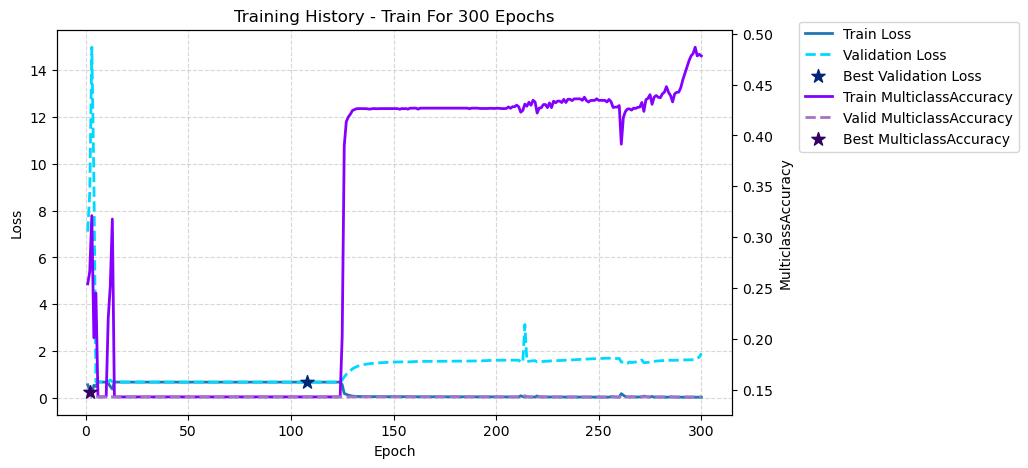

In [17]:
plot_training_history(history, 
                      name="Train For 300 Epochs", 
                      save_path="assets/", 
                      show_best_loss=True, 
                      show_best_metric=True)